In [1]:
import re
import os
import ast
import matplotlib
from dataclasses import dataclass, field
from collections import defaultdict
MATCH_PARA = re.compile(r'(\w+)\s+([\d.]+)')
import matplotlib.pyplot as plt
import math
from Utils import *
from matplotlib.ticker import FixedLocator


In [2]:
data_path = "quantum_network_compiler-minimal_codes/FIG_dataset_rebuttal"
current_dir = os.getcwd()
parent_dir = os.path.dirname(os.path.dirname(current_dir))
absolute_path = os.path.join(parent_dir, data_path)
data_path = str(os.path.abspath(absolute_path))
data_path_to_execute = data_path + '/cache_size'
data_path_list = [data_path+'/inter_time']
eval = ['cache_size']
benchmark = ['xor','qft','grover','rca','qaoa']
big_list = process_files_by_seed(data_path_to_execute)
line_width = 3
marker_size = 8

def grab_data(big_list,eval_key):
    metric_sums = defaultdict(lambda: {'metric_t_sum': 0.0, 'metric_w_sum': 0.0,'epr_sum':0.0, 'count': 0,'in':0,'cross':0,'post':0})
    for sublist in big_list:
        for instance in sublist:
            filtered_file_p = {k: v for k, v in instance.file_p.items() if k != 'seed'}
            # if 'baseline'
            file_p_key = frozenset(filtered_file_p.items())
            metric_sums[file_p_key]['metric_t_sum'] += instance.dic_l4['thruput']
            metric_sums[file_p_key]['metric_w_sum'] += instance.dic_l4['avg_wait_time']
            metric_sums[file_p_key]['epr_sum'] += instance.epr
            metric_sums[file_p_key]['count'] += 1
            metric_sums[file_p_key]['in']  = instance.dic_l2['in_pair']
            metric_sums[file_p_key]['cross']  = instance.dic_l2['cross_pair']
            metric_sums[file_p_key]['post']  = instance.dic_l2['post_in_pair']
    averages = []
    for file_p_key, values in metric_sums.items():
        avg_metric_t = values['metric_t_sum'] / values['count']
        avg_metric_w = values['metric_w_sum'] / values['count']
        epr = values['epr_sum'] / values['count']
        # print( values['count'])
        averages.append({'file_p': dict(file_p_key), 'avg_metric_t': avg_metric_t, 'avg_metric_w': avg_metric_w, 'eproverhead':epr,'in':values['in'],'cross':values['cross'],'post':values['post']})
    return averages
averages = grab_data(big_list, eval[0])
result_base = classify_and_sort_averages_1(averages, eval[0], our=0)
diction = [[[], [], [], [], []], [[], [], [], [], []], [[], [], [], [], []]]
for index, b in enumerate(benchmark):
    for aa in result_base[b]:
        diction[0][index].append(aa['cross'])
        diction[1][index].append(aa['in'])
        diction[2][index].append(aa['post'])
mct_data, qft_data, grover_data, rca_data, qaoa_data = extract_data(diction,baseline=False)
mct_baseline ,qft_baseline ,grover_baseline ,rca_baseline, qaoa_baseline =  extract_data(diction,baseline=True)

In [3]:

split_mul = 2
xrange_cross = [1/3 * a for a in [5,4.5,4,3.5,3,2.5,2,1.5,1]]
xrange=[1,2,3,4,5,6,7,8,9]
xlabel = [f"{75/95:.2f}", '', f"{80/95:.2f}", '', f"{85/95:.2f}", '', f"{90/95:.2f}", '', f"{95/95:.2f}"]
def calculate_overhead_data_cross(raw_data, baseline, split, xrange):
    result = []
    for i in xrange:
        overhead = ((raw_data[0] * i + raw_data[1] / 3 + math.pow(0.7,split-1)/3 * raw_data[2]) / (baseline[0]*i + baseline[1] / 3 + math.pow(0.7, split-1)/3 * baseline[2]) - 1 ) * 100
        # print(overhead)
        result.append(overhead)
    return result
mct = calculate_overhead_data_cross(mct_data,mct_baseline,split=split_mul,xrange=xrange_cross)
qft = calculate_overhead_data_cross(qft_data,qft_baseline,split=split_mul,xrange=xrange_cross)
grover = calculate_overhead_data_cross(grover_data,grover_baseline,split=split_mul,xrange=xrange_cross)
rca = calculate_overhead_data_cross(rca_data, rca_baseline,split=split_mul,xrange=xrange_cross)
qaoa = calculate_overhead_data_cross(qaoa_data, qaoa_baseline,split=split_mul,xrange=xrange_cross)

In [4]:
len(rca_data)

3

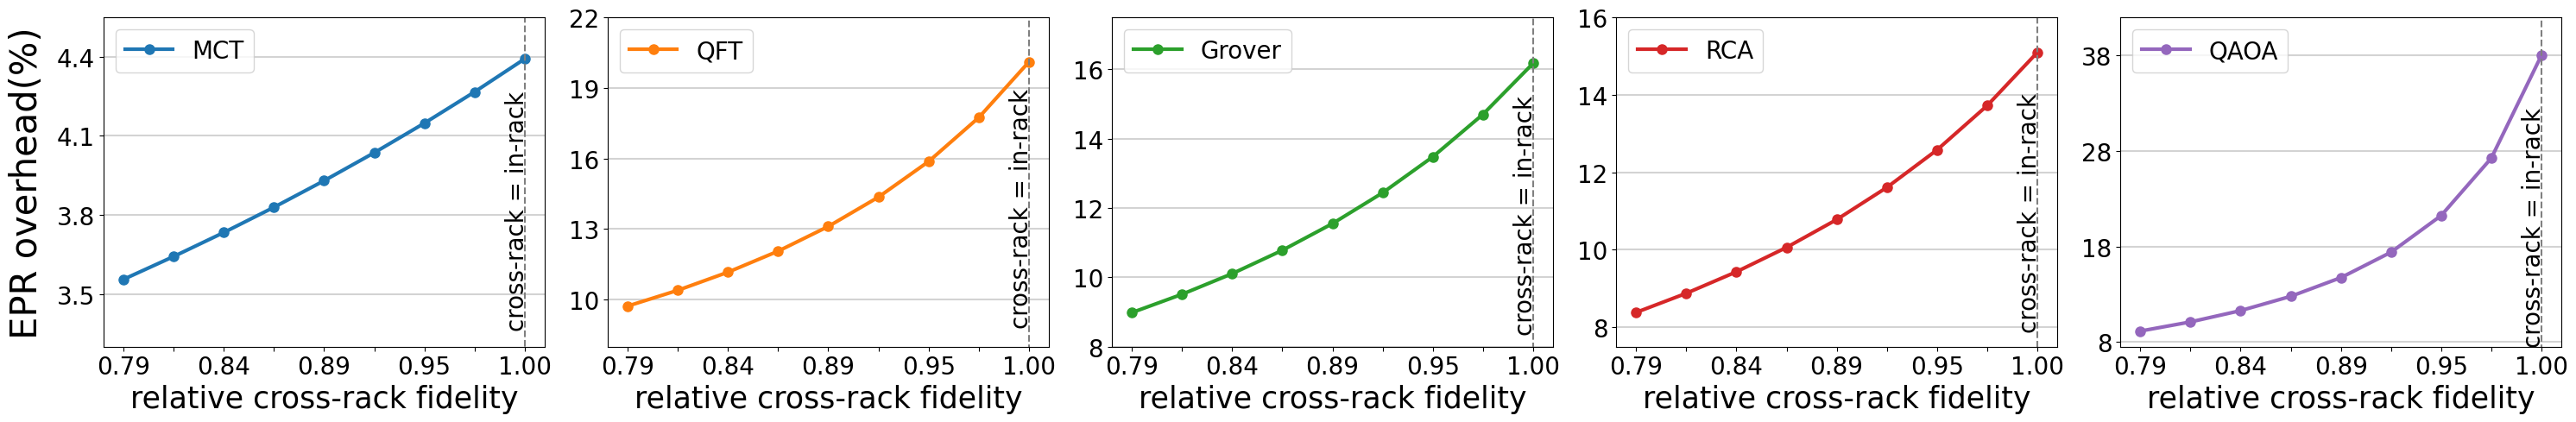

In [17]:
fig, axs = plt.subplots(1,5,figsize = (30,5))
tick_font = 20
axs[0].plot(xrange,mct,label = 'MCT',color = 'C0',marker='o',linestyle = '-', linewidth=line_width,markersize=marker_size)

axs[1].plot(xrange,qft,label = 'QFT',color = 'C1',marker='o',linestyle = '-', linewidth=line_width,markersize=marker_size)
axs[1].set_ylim(7,18)

axs[2].plot(xrange,grover,label = 'Grover',color = 'C2',marker='o',linestyle = '-', linewidth=line_width,markersize=marker_size)
axs[2].set_ylim(6,14)

axs[3].plot(xrange,rca,label = 'RCA',color = 'C3',marker='o',linestyle = '-', linewidth=line_width,markersize=marker_size)
axs[3].set_ylim(6,14)

axs[4].plot(xrange,qaoa,label = 'QAOA',color = 'C4',marker='o',linestyle = '-', linewidth=line_width,markersize=marker_size)
axs[4].set_ylim(6,45)


for i in range(5):
    axs[i].set_xticks(xrange) 
    axs[i].set_xticklabels(xlabel,fontsize = 20,color='black')
    axs[i].tick_params(axis = 'y', labelsize = tick_font)
    axs[i].legend(loc = 'upper left', fontsize = 20)
    axs[i].grid(True, which = 'both', axis = 'y', linestyle = '-', linewidth = 1.5, color = 'lightgray')
    axs[i].set_xlabel('relative cross-rack fidelity', fontsize = 25)

axs[0].set_ylabel('EPR overhead(%)', fontsize = 30,color = 'black', labelpad = 10)

axs[0].set_ylim(3.3,4.55)
axs[1].set_ylim(8,22)
axs[2].set_ylim(8,17.5)
axs[3].set_ylim(7.5,16)
axs[4].set_ylim(7.5,42)


axs[0].vlines(9,ymin = 2.1,ymax = 6, color = 'gray', linestyles='dashed', linewidth=1.5 )
axs[1].vlines(9,ymin = 7,ymax = 30, color = 'gray', linestyles='dashed', linewidth=1.5 )
axs[2].vlines(9,ymin = 6,ymax = 30, color = 'gray', linestyles='dashed', linewidth=1.5 )
axs[3].vlines(9,ymin = 6,ymax = 20, color = 'gray', linestyles='dashed', linewidth=1.5 )
axs[4].vlines(9,ymin = 6,ymax = 42, color = 'gray', linestyles='dashed', linewidth=1.5 )


axs[0].text(8.6, 3.38, 'cross-rack = in-rack', fontsize = 20,rotation = 90)
axs[1].text(8.6, 9, 'cross-rack = in-rack', fontsize = 20, rotation = 90)
axs[2].text(8.6, 8.5, 'cross-rack = in-rack', fontsize = 20,rotation = 90)
axs[3].text(8.6,8, 'cross-rack = in-rack', fontsize = 20,rotation = 90)
axs[4].text(8.6,8, 'cross-rack = in-rack', fontsize = 20,rotation = 90)


axs[0].yaxis.set_major_locator(FixedLocator([3.50,3.8,4.1,4.4]))
axs[1].yaxis.set_major_locator(FixedLocator([10,13,16,19,22]))
axs[2].yaxis.set_major_locator(FixedLocator([8,10,12,14,16,18,20]))
axs[3].yaxis.set_major_locator(FixedLocator([8,10,12,14,16]))
axs[4].yaxis.set_major_locator(FixedLocator([8,18,28,38,48]))


plt.tight_layout()
plt.savefig('fig/FIG_10a.pdf', bbox_inches='tight')
plt.show()

In [20]:
split_mul = 2
xrange_cross = [1/3 * a for a in [1,0.9,0.8,0.7,0.6,0.5,0.4,0.3,0.2,0.1]]
xrange=[1,2,3,4,5,6,7,8,9,10]
xlabel = [f"{95/95:.2f}", '', f"{96/95:.2f}", '', f"{97/95:.2f}", '', f"{98/95:.2f}", '', f"{99/95:.2f}",'']
def calculate_overhead_data_cross(raw_data, baseline, split, xrange):
    result = []
    for i in xrange:
        overhead = ((raw_data[0]  + raw_data[1] / 3 + math.pow(0.7,split-1) * i * raw_data[2]) / (baseline[0] + baseline[1] / 3 ) - 1 ) * 100
        result.append(overhead)
    return result
mct = calculate_overhead_data_cross(mct_data,mct_baseline,split=split_mul,xrange=xrange_cross)
qft = calculate_overhead_data_cross(qft_data,qft_baseline,split=split_mul,xrange=xrange_cross)
grover = calculate_overhead_data_cross(grover_data,grover_baseline,split=split_mul,xrange=xrange_cross)
rca = calculate_overhead_data_cross(rca_data, rca_baseline,split=split_mul,xrange=xrange_cross)
qaoa = calculate_overhead_data_cross(qaoa_data, qaoa_baseline,split=split_mul,xrange=xrange_cross)


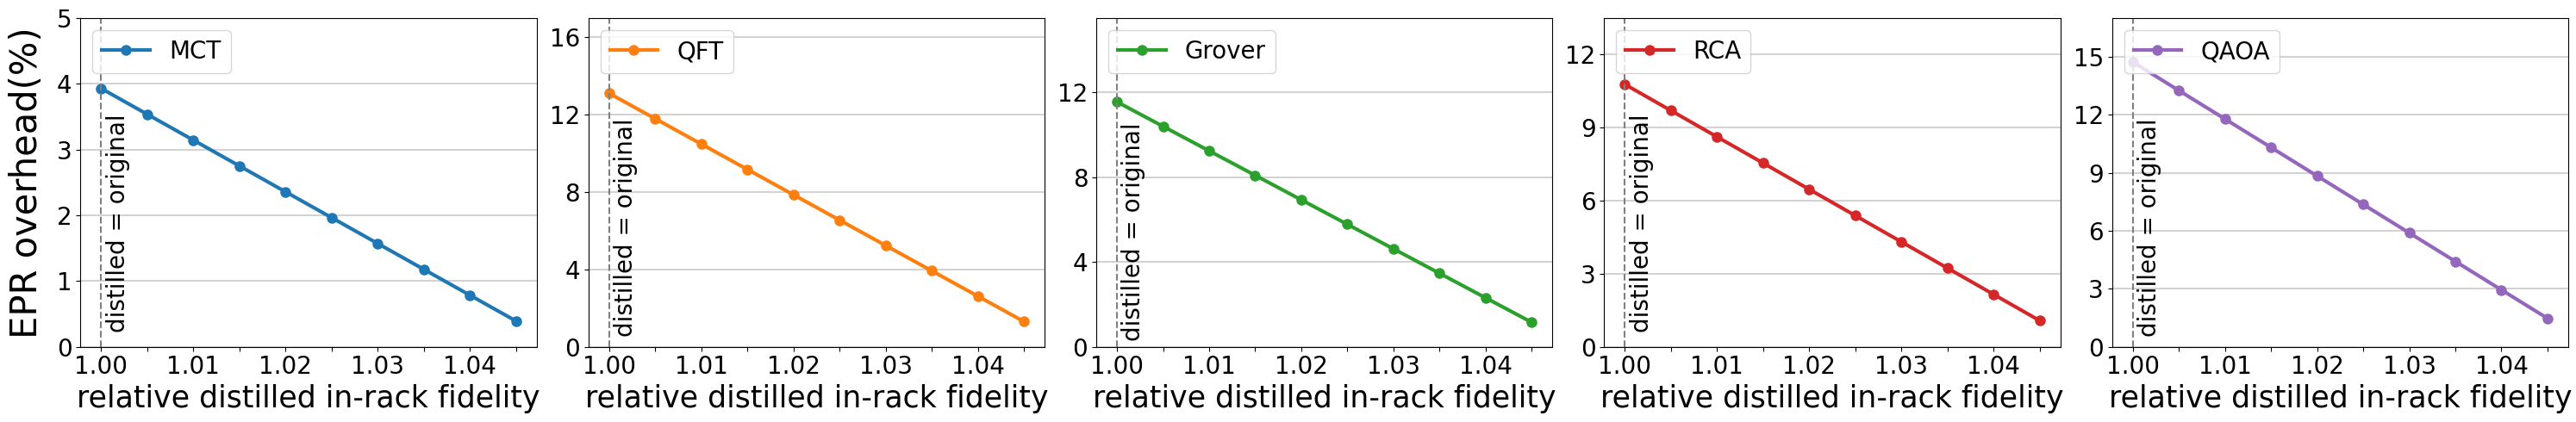

In [24]:
fig, axs = plt.subplots(1,5,figsize = (30,5))
tick_font = 20
axs[0].plot(xrange,mct,label = 'MCT',color = 'C0',marker='o',linestyle = '-', linewidth=line_width,markersize=marker_size)
axs[1].plot(xrange,qft,label = 'QFT',color = 'C1',marker='o',linestyle = '-', linewidth=line_width,markersize=marker_size)
axs[2].plot(xrange,grover,label = 'Grover',color = 'C2',marker='o',linestyle = '-', linewidth=line_width,markersize=marker_size)
axs[3].plot(xrange,rca,label = 'RCA',color = 'C3',marker='o',linestyle = '-', linewidth=line_width,markersize=marker_size)
axs[4].plot(xrange,qaoa,label = 'QAOA',color = 'C4',marker='o',linestyle = '-', linewidth=line_width,markersize=marker_size)



for i in range(5):
    axs[i].set_xticks(xrange) 
    axs[i].set_xticklabels(xlabel,fontsize = 20,color='black')
    axs[i].tick_params(axis = 'y', labelsize = tick_font)
    axs[i].legend(loc = 'upper left', fontsize = 20)
    axs[i].grid(True, which = 'both', axis = 'y', linestyle = '-', linewidth = 1.5, color = 'lightgray')
    axs[i].set_xlabel('relative distilled in-rack fidelity', fontsize = 25)

axs[0].set_ylabel('EPR overhead(%)', fontsize = 30,color = 'black', labelpad = 10)
axs[0].vlines(1,ymin = 0,ymax = 5, color = 'gray', linestyles='dashed', linewidth=1.5 )
axs[1].vlines(1,ymin = 0,ymax = 20, color = 'gray', linestyles='dashed', linewidth=1.5 )
axs[2].vlines(1,ymin = 0,ymax = 20, color = 'gray', linestyles='dashed', linewidth=1.5 )
axs[3].vlines(1,ymin = 0,ymax = 20, color = 'gray', linestyles='dashed', linewidth=1.5 )
axs[4].vlines(1,ymin = 0,ymax = 20, color = 'gray', linestyles='dashed', linewidth=1.5 )


axs[0].set_ylim(0,5)
axs[1].set_ylim(0,17)
axs[2].set_ylim(0,15.5)
axs[3].set_ylim(0,13.5)
axs[4].set_ylim(0,17)
axs[3].yaxis.set_major_locator(FixedLocator([0,5,10]))


axs[0].text(1.1, 0.3, 'distilled = original', fontsize = 20,rotation = 90)
axs[1].text(1.1, 0.8, 'distilled = original', fontsize = 20,rotation = 90)
axs[2].text(1.1, 0.5, 'distilled = original', fontsize = 20,rotation = 90)
axs[3].text(1.1, 0.8, 'distilled = original', fontsize = 20,rotation = 90)
axs[4].text(1.1, 0.8, 'distilled = original', fontsize = 20,rotation = 90)


axs[0].yaxis.set_major_locator(FixedLocator([0,1,2,3,4,5,6]))
axs[1].yaxis.set_major_locator(FixedLocator([0,4,8,12,16]))
axs[2].yaxis.set_major_locator(FixedLocator([0,4,8,12,16]))
axs[3].yaxis.set_major_locator(FixedLocator([0,3,6,9,12,15]))
axs[4].yaxis.set_major_locator(FixedLocator([0,3,6,9,12,15]))


plt.tight_layout()
plt.savefig('fig/FIG_10b.pdf', bbox_inches='tight')
plt.show()